<a href="https://colab.research.google.com/github/Asifr001/Pediatric-Non-Accidental-Trauma-Covid-trends/blob/main/Pediatric_Physical_Abuse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Loading the data

df = pd.read_excel("Physical Abuse - Final.xlsx")

In [ ]:
# Show column names
print(df.columns)

Index(['PrimaryMrn', 'CurrentAge', 'Age_Years_At_Abuse', 'Age Category',
       'Age_Months_At_Abuse', 'FirstRace', 'Ethnicity', 'CurrentZip', 'Zip',
       'DCI Quintile', 'Category', 'RUCA', 'Rural_vs_Urban', 'CurrentState',
       'Zip_At_Diagnosis', 'State_At_Diagnosis', 'PayorFinancialClass',
       'AdmissionInstant', 'DischargeInstant', 'DischargeDisposition',
       'Death Instant (date)', 'Death Instant (binary)', 'AdmissionType',
       'ArrivalMeans', 'ICD_Codes', 'Unnamed: 25', 'Physical Abuse?',
       'Sexual Abuse?', 'Psychological Abuse?', 'Neglect or abandonment',
       'Other or Unspecified'],
      dtype='object')


In [ ]:
# ── Install / import ─────────────────────────────
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import kruskal, chi2_contingency, fisher_exact


# Ensure AdmissionInstant is datetime
df["AdmissionInstant"] = pd.to_datetime(df["AdmissionInstant"])


# ── 2. ASSIGN TIME PERIODS ─────────────────────────────────────────────────────
before_start = pd.Timestamp("2010-01-01")
before_end   = pd.Timestamp("2020-02-29")
covid_start  = pd.Timestamp("2020-03-01")
covid_end    = pd.Timestamp("2021-03-31")
after_start  = pd.Timestamp("2021-04-01")
after_end    = pd.Timestamp("2024-02-28")

def assign_period(dt):
    if before_start <= dt <= before_end:
        return "Before COVID-19"
    elif covid_start <= dt <= covid_end:
        return "COVID-19"
    elif after_start <= dt <= after_end:
        return "After COVID-19"
    else:
        return "Out of Range"

df["Period"] = df["AdmissionInstant"].apply(assign_period)

period_order = ["Before COVID-19", "COVID-19", "After COVID-19"]
df_valid = df[df["Period"] != "Out of Range"].copy()

# Subsets per period
before = df_valid[df_valid["Period"] == "Before COVID-19"]
covid  = df_valid[df_valid["Period"] == "COVID-19"]
after  = df_valid[df_valid["Period"] == "After COVID-19"]

print(f"\nEncounters by period:")
print(f"  Before COVID-19 : {len(before)}")
print(f"  COVID-19        : {len(covid)}")
print(f"  After COVID-19  : {len(after)}")
print(f"  Total (valid)   : {len(df_valid)}")

# ── HELPER: build result rows ──────────────────────────────────────────────────
def fmt_n_pct(n, total):
    """Return 'n (x.x%)'"""
    return f"{n} ({100*n/total:.1f}%)" if total > 0 else "0 (0.0%)"

# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 1 – Number of Encounters
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("1. NUMBER OF ENCOUNTERS")
print("="*70)
print(f"  Total          : {len(df_valid)}")
print(f"  Before COVID-19: {len(before)}")
print(f"  COVID-19       : {len(covid)}")
print(f"  After COVID-19 : {len(after)}")




Encounters by period:
  Before COVID-19 : 144
  COVID-19        : 56
  After COVID-19  : 307
  Total (valid)   : 507

1. NUMBER OF ENCOUNTERS
  Total          : 507
  Before COVID-19: 144
  COVID-19       : 56
  After COVID-19 : 307


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 2 – Median Age (years) [IQR], used Kruskal-Wallis for p-value
# ═══════════════════════════════════════════════════════════════════════════════
age_col = "Age_Years_At_Abuse"

def median_iqr(series):
    q1  = series.quantile(0.25)
    med = series.median()
    q3  = series.quantile(0.75)
    return med, q1, q3

print("\n" + "="*70)
print("2. MEDIAN AGE (years) [IQR]  — using Age_Years_At_Abuse")
print("="*70)

groups = [before[age_col].dropna(), covid[age_col].dropna(), after[age_col].dropna()]
kw_stat, kw_p = kruskal(*groups)

for label, subset in [("Total", df_valid), ("Before COVID-19", before),
                       ("COVID-19", covid), ("After COVID-19", after)]:
    med, q1, q3 = median_iqr(subset[age_col].dropna())
    print(f"  {label:<20}: Median = {med:.1f}  [IQR: {q1:.1f} – {q3:.1f}]")

print(f"\n  Kruskal-Wallis p-value (3 periods): p = {kw_p:.3f}")


2. MEDIAN AGE (years) [IQR]  — using Age_Years_At_Abuse
  Total               : Median = 1.0  [IQR: 0.0 – 4.0]
  Before COVID-19     : Median = 2.0  [IQR: 0.0 – 8.0]
  COVID-19            : Median = 2.0  [IQR: 0.0 – 4.0]
  After COVID-19      : Median = 0.0  [IQR: 0.0 – 3.0]

  Kruskal-Wallis p-value (3 periods): p = 0.000


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 3 – Mean Age (years), used One-way ANOVA for p-value
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("3. MEAN AGE (years)  — using Age_Years_At_Abuse")
print("="*70)

f_stat, anova_p = stats.f_oneway(*groups)

for label, subset in [("Total", df_valid), ("Before COVID-19", before),
                       ("COVID-19", covid), ("After COVID-19", after)]:
    mn  = subset[age_col].mean()
    sd  = subset[age_col].std()
    print(f"  {label:<20}: Mean = {mn:.2f}  (SD = {sd:.2f})")

print(f"\n  One-way ANOVA p-value (3 periods): p = {anova_p:.3f}")



3. MEAN AGE (years)  — using Age_Years_At_Abuse
  Total               : Mean = 3.11  (SD = 4.41)
  Before COVID-19     : Mean = 4.24  (SD = 4.74)
  COVID-19            : Mean = 2.46  (SD = 2.76)
  After COVID-19      : Mean = 2.70  (SD = 4.42)

  One-way ANOVA p-value (3 periods): p = 0.001


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 4 – Age Categories, used Chi-square for p-value
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("4. AGE CATEGORIES  (Age Category column)")
print("="*70)

age_cats = ["Infant (<1)", "Toddler (1-2)", "Preschool age (3-5)",
            "School age (6-11)", "Adolescent (12-17)"]

# Standardise any label spacing issues
df_valid["Age Category"] = df_valid["Age Category"].str.strip()

# Build contingency table for chi-square (exclude unknowns)
ct_age = pd.crosstab(df_valid["Age Category"],
                     df_valid["Period"])[period_order].reindex(age_cats, fill_value=0)

chi2_age, p_age, dof_age, _ = chi2_contingency(ct_age)

# Print results
for cat in age_cats:
    row_vals = []
    total_n  = df_valid["Age Category"].value_counts().get(cat, 0)
    row_vals.append(fmt_n_pct(total_n, len(df_valid)))
    for subset, period in [(before, "Before COVID-19"), (covid, "COVID-19"), (after, "After COVID-19")]:
        n   = (subset["Age Category"] == cat).sum()
        row_vals.append(fmt_n_pct(n, len(subset)))
    print(f"  {cat:<25}: Total={row_vals[0]}  Before={row_vals[1]}  "
          f"COVID={row_vals[2]}  After={row_vals[3]}")

print(f"\n  Chi-square p-value (3 periods): χ²={chi2_age:.2f}, df={dof_age}, p = {p_age:.3f}")


4. AGE CATEGORIES  (Age Category column)
  Infant (<1)              : Total=218 (43.0%)  Before=43 (29.9%)  COVID=20 (35.7%)  After=155 (50.5%)
  Toddler (1-2)            : Total=98 (19.3%)  Before=31 (21.5%)  COVID=13 (23.2%)  After=54 (17.6%)
  Preschool age (3-5)      : Total=96 (18.9%)  Before=28 (19.4%)  COVID=18 (32.1%)  After=50 (16.3%)
  School age (6-11)        : Total=49 (9.7%)  Before=27 (18.8%)  COVID=3 (5.4%)  After=19 (6.2%)
  Adolescent (12-17)       : Total=46 (9.1%)  Before=15 (10.4%)  COVID=2 (3.6%)  After=29 (9.4%)

  Chi-square p-value (3 periods): χ²=37.48, df=8, p = 0.000


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 5 – Primary Insurance, used Chi-square for p-value
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("5. PRIMARY INSURANCE  (PayorFinancialClass column)")
print("="*70)

medicaid_keywords = ["medicaid", "medicare"]  # case-insensitive match

def classify_insurance(val):
    if pd.isna(val):
        return "Other"
    v = str(val).lower().strip()
    if any(k in v for k in medicaid_keywords):
        return "Medicaid"
    elif "private" in v or "commercial" in v or "blue" in v or "aetna" in v \
         or "cigna" in v or "united" in v or "humana" in v or "bcbs" in v:
        return "Private"
    else:
        return "Other"

df_valid["Insurance_Class"] = df_valid["PayorFinancialClass"].apply(classify_insurance)
before["Insurance_Class"]   = before["PayorFinancialClass"].apply(classify_insurance)
covid["Insurance_Class"]    = covid["PayorFinancialClass"].apply(classify_insurance)
after["Insurance_Class"]    = after["PayorFinancialClass"].apply(classify_insurance)

ins_cats = ["Medicaid", "Private", "Other"]

ct_ins = pd.crosstab(df_valid["Insurance_Class"],
                     df_valid["Period"])[period_order].reindex(ins_cats, fill_value=0)
chi2_ins, p_ins, dof_ins, _ = chi2_contingency(ct_ins)

for cat in ins_cats:
    total_n = (df_valid["Insurance_Class"] == cat).sum()
    row_vals = [fmt_n_pct(total_n, len(df_valid))]
    for subset in [before, covid, after]:
        n = (subset["Insurance_Class"] == cat).sum()
        row_vals.append(fmt_n_pct(n, len(subset)))
    print(f"  {cat:<12}: Total={row_vals[0]}  Before={row_vals[1]}  "
          f"COVID={row_vals[2]}  After={row_vals[3]}")

print(f"\n  Chi-square p-value (3 periods): χ²={chi2_ins:.2f}, df={dof_ins}, p = {p_ins:.3f}")




5. PRIMARY INSURANCE  (PayorFinancialClass column)
  Medicaid    : Total=429 (84.6%)  Before=117 (81.2%)  COVID=48 (85.7%)  After=264 (86.0%)
  Private     : Total=50 (9.9%)  Before=12 (8.3%)  COVID=7 (12.5%)  After=31 (10.1%)
  Other       : Total=28 (5.5%)  Before=15 (10.4%)  COVID=1 (1.8%)  After=12 (3.9%)

  Chi-square p-value (3 periods): χ²=10.13, df=4, p = 0.038


/tmp/ipykernel_9603/2163368994.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  before["Insurance_Class"]   = before["PayorFinancialClass"].apply(classify_insurance)
/tmp/ipykernel_9603/2163368994.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  covid["Insurance_Class"]    = covid["PayorFinancialClass"].apply(classify_insurance)
/tmp/ipykernel_9603/2163368994.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = v

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 6 – Race / Ethnicity, used Chi-square for p-value
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("6. RACE / ETHNICITY  (Ethnicity column)")
print("="*70)

def classify_ethnicity(val):
    if pd.isna(val):
        return "Other"
    v = str(val).strip()
    if v == "Hispanic":
        return "Hispanic"
    elif v == "Non-Hispanic":
        return "Non-Hispanic"
    else:
        return "Other"

df_valid["Ethnicity_Class"] = df_valid["Ethnicity"].apply(classify_ethnicity)
before["Ethnicity_Class"]   = before["Ethnicity"].apply(classify_ethnicity)
covid["Ethnicity_Class"]    = covid["Ethnicity"].apply(classify_ethnicity)
after["Ethnicity_Class"]    = after["Ethnicity"].apply(classify_ethnicity)

eth_cats = ["Hispanic", "Non-Hispanic", "Other"]

ct_eth = pd.crosstab(df_valid["Ethnicity_Class"],
                     df_valid["Period"])[period_order].reindex(eth_cats, fill_value=0)
chi2_eth, p_eth, dof_eth, _ = chi2_contingency(ct_eth)

for cat in eth_cats:
    total_n = (df_valid["Ethnicity_Class"] == cat).sum()
    row_vals = [fmt_n_pct(total_n, len(df_valid))]
    for subset in [before, covid, after]:
        n = (subset["Ethnicity_Class"] == cat).sum()
        row_vals.append(fmt_n_pct(n, len(subset)))
    print(f"  {cat:<15}: Total={row_vals[0]}  Before={row_vals[1]}  "
          f"COVID={row_vals[2]}  After={row_vals[3]}")

print(f"\n  Chi-square p-value (3 periods): χ²={chi2_eth:.2f}, df={dof_eth}, p = {p_eth:.3f}")

print("\n  >> Unique Ethnicity values (check these!):")
print(" ", df["Ethnicity"].dropna().unique())


6. RACE / ETHNICITY  (Ethnicity column)
  Hispanic       : Total=5 (1.0%)  Before=2 (1.4%)  COVID=0 (0.0%)  After=3 (1.0%)
  Non-Hispanic   : Total=490 (96.6%)  Before=139 (96.5%)  COVID=55 (98.2%)  After=296 (96.4%)
  Other          : Total=12 (2.4%)  Before=3 (2.1%)  COVID=1 (1.8%)  After=8 (2.6%)

  Chi-square p-value (3 periods): χ²=1.01, df=4, p = 0.909

  >> Unique Ethnicity values (check these!):
  ['Non-Hispanic' 'Unknown' 'Hispanic' 'Patient Refused']


/tmp/ipykernel_9603/1873174133.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  before["Ethnicity_Class"]   = before["Ethnicity"].apply(classify_ethnicity)
/tmp/ipykernel_9603/1873174133.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  covid["Ethnicity_Class"]    = covid["Ethnicity"].apply(classify_ethnicity)
/tmp/ipykernel_9603/1873174133.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 7 – RUCA Category (Rural vs Urban), used Chi-square for p-value
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("7. RUCA CATEGORY  (Rural_vs_Urban column)")
print("="*70)

def classify_ruca(val):
    if pd.isna(val) or str(val).strip() == "":
        return "Unknown"
    v = str(val).strip()
    if v == "Rural":
        return "Rural"
    elif v == "Urban":
        return "Urban"
    else:
        return "Unknown"

df_valid["RUCA_Class"] = df_valid["Rural_vs_Urban"].apply(classify_ruca)
before["RUCA_Class"]   = before["Rural_vs_Urban"].apply(classify_ruca)
covid["RUCA_Class"]    = covid["Rural_vs_Urban"].apply(classify_ruca)
after["RUCA_Class"]    = after["Rural_vs_Urban"].apply(classify_ruca)

ruca_cats = ["Urban", "Rural", "Unknown"]

# Chi-square only on Rural vs Urban rows (exclude Unknown)
ct_ruca_chi = pd.crosstab(
    df_valid[df_valid["RUCA_Class"] != "Unknown"]["RUCA_Class"],
    df_valid[df_valid["RUCA_Class"] != "Unknown"]["Period"]
)[period_order].reindex(["Urban", "Rural"], fill_value=0)

# Use Fisher's exact if any cell < 5, otherwise chi-square
min_cell = ct_ruca_chi.values.min()
if ct_ruca_chi.shape == (2, 3):
    chi2_ruca, p_ruca, dof_ruca, _ = chi2_contingency(ct_ruca_chi)
    test_name = "Chi-square"
else:
    p_ruca = None
    test_name = "N/A"

for cat in ruca_cats:
    total_n = (df_valid["RUCA_Class"] == cat).sum()
    row_vals = [fmt_n_pct(total_n, len(df_valid))]
    for subset in [before, covid, after]:
        n = (subset["RUCA_Class"] == cat).sum()
        row_vals.append(fmt_n_pct(n, len(subset)))
    print(f"  {cat:<10}: Total={row_vals[0]}  Before={row_vals[1]}  "
          f"COVID={row_vals[2]}  After={row_vals[3]}")

if p_ruca is not None:
    print(f"\n  {test_name} p-value (Urban vs Rural, 3 periods): "
          f"χ²={chi2_ruca:.2f}, df={dof_ruca}, p = {p_ruca:.3f}")
    print("  (Note: 'Unknown' rows excluded from statistical test)")

# We need to correct this. 3 will be unknown. Deduct 3 from rural


7. RUCA CATEGORY  (Rural_vs_Urban column)
  Urban     : Total=232 (45.8%)  Before=75 (52.1%)  COVID=26 (46.4%)  After=131 (42.7%)
  Rural     : Total=272 (53.6%)  Before=69 (47.9%)  COVID=29 (51.8%)  After=174 (56.7%)
  Unknown   : Total=3 (0.6%)  Before=0 (0.0%)  COVID=1 (1.8%)  After=2 (0.7%)

  Chi-square p-value (Urban vs Rural, 3 periods): χ²=3.32, df=2, p = 0.190
  (Note: 'Unknown' rows excluded from statistical test)


/tmp/ipykernel_9603/3757833184.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  before["RUCA_Class"]   = before["Rural_vs_Urban"].apply(classify_ruca)
/tmp/ipykernel_9603/3757833184.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  covid["RUCA_Class"]    = covid["Rural_vs_Urban"].apply(classify_ruca)
/tmp/ipykernel_9603/3757833184.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("CLEAN SUMMARY TABLE (Table 1)")
print("="*70)

rows = []

# Encounters
rows.append({"Variable": "Number of Encounters",
             "Total": len(df_valid),
             "Before COVID-19": len(before),
             "COVID-19": len(covid),
             "After COVID-19": len(after),
             "p-value": ""})

# Median age
med_t, q1_t, q3_t = median_iqr(df_valid[age_col].dropna())
med_b, q1_b, q3_b = median_iqr(before[age_col].dropna())
med_c, q1_c, q3_c = median_iqr(covid[age_col].dropna())
med_a, q1_a, q3_a = median_iqr(after[age_col].dropna())
rows.append({"Variable": "Median Age [IQR]",
             "Total":           f"{med_t:.1f} [{q1_t:.1f}–{q3_t:.1f}]",
             "Before COVID-19": f"{med_b:.1f} [{q1_b:.1f}–{q3_b:.1f}]",
             "COVID-19":        f"{med_c:.1f} [{q1_c:.1f}–{q3_c:.1f}]",
             "After COVID-19":  f"{med_a:.1f} [{q1_a:.1f}–{q3_a:.1f}]",
             "p-value": f"{kw_p:.3f}"})

# Mean age
rows.append({"Variable": "Mean Age (SD)",
             "Total":           f"{df_valid[age_col].mean():.2f} ({df_valid[age_col].std():.2f})",
             "Before COVID-19": f"{before[age_col].mean():.2f} ({before[age_col].std():.2f})",
             "COVID-19":        f"{covid[age_col].mean():.2f} ({covid[age_col].std():.2f})",
             "After COVID-19":  f"{after[age_col].mean():.2f} ({after[age_col].std():.2f})",
             "p-value": f"{anova_p:.3f}"})

# Age categories
rows.append({"Variable": "Age Categories", "Total": "", "Before COVID-19": "",
             "COVID-19": "", "After COVID-19": "", "p-value": f"{p_age:.3f}"})
for cat in age_cats:
    n_t = (df_valid["Age Category"] == cat).sum()
    n_b = (before["Age Category"] == cat).sum()
    n_c = (covid["Age Category"] == cat).sum()
    n_a = (after["Age Category"] == cat).sum()
    rows.append({"Variable": f"  {cat}",
                 "Total":           fmt_n_pct(n_t, len(df_valid)),
                 "Before COVID-19": fmt_n_pct(n_b, len(before)),
                 "COVID-19":        fmt_n_pct(n_c, len(covid)),
                 "After COVID-19":  fmt_n_pct(n_a, len(after)),
                 "p-value": ""})

# Insurance
rows.append({"Variable": "Primary Insurance", "Total": "", "Before COVID-19": "",
             "COVID-19": "", "After COVID-19": "", "p-value": f"{p_ins:.3f}"})
for cat in ins_cats:
    n_t = (df_valid["Insurance_Class"] == cat).sum()
    n_b = (before["Insurance_Class"] == cat).sum()
    n_c = (covid["Insurance_Class"] == cat).sum()
    n_a = (after["Insurance_Class"] == cat).sum()
    rows.append({"Variable": f"  {cat}",
                 "Total":           fmt_n_pct(n_t, len(df_valid)),
                 "Before COVID-19": fmt_n_pct(n_b, len(before)),
                 "COVID-19":        fmt_n_pct(n_c, len(covid)),
                 "After COVID-19":  fmt_n_pct(n_a, len(after)),
                 "p-value": ""})

# Ethnicity
rows.append({"Variable": "Race/Ethnicity", "Total": "", "Before COVID-19": "",
             "COVID-19": "", "After COVID-19": "", "p-value": f"{p_eth:.3f}"})
for cat in eth_cats:
    n_t = (df_valid["Ethnicity_Class"] == cat).sum()
    n_b = (before["Ethnicity_Class"] == cat).sum()
    n_c = (covid["Ethnicity_Class"] == cat).sum()
    n_a = (after["Ethnicity_Class"] == cat).sum()
    rows.append({"Variable": f"  {cat}",
                 "Total":           fmt_n_pct(n_t, len(df_valid)),
                 "Before COVID-19": fmt_n_pct(n_b, len(before)),
                 "COVID-19":        fmt_n_pct(n_c, len(covid)),
                 "After COVID-19":  fmt_n_pct(n_a, len(after)),
                 "p-value": ""})

# RUCA
rows.append({"Variable": "RUCA Category", "Total": "", "Before COVID-19": "",
             "COVID-19": "", "After COVID-19": "",
             "p-value": f"{p_ruca:.3f}" if p_ruca else ""})
for cat in ruca_cats:
    n_t = (df_valid["RUCA_Class"] == cat).sum()
    n_b = (before["RUCA_Class"] == cat).sum()
    n_c = (covid["RUCA_Class"] == cat).sum()
    n_a = (after["RUCA_Class"] == cat).sum()
    rows.append({"Variable": f"  {cat}",
                 "Total":           fmt_n_pct(n_t, len(df_valid)),
                 "Before COVID-19": fmt_n_pct(n_b, len(before)),
                 "COVID-19":        fmt_n_pct(n_c, len(covid)),
                 "After COVID-19":  fmt_n_pct(n_a, len(after)),
                 "p-value": ""})

# Print and optionally export
summary_df = pd.DataFrame(rows, columns=["Variable", "Total",
                                          "Before COVID-19", "COVID-19",
                                          "After COVID-19", "p-value"])
print(summary_df.to_string(index=False))


CLEAN SUMMARY TABLE (Table 1)
             Variable         Total Before COVID-19      COVID-19 After COVID-19 p-value
 Number of Encounters           507             144            56            307        
     Median Age [IQR] 1.0 [0.0–4.0]   2.0 [0.0–8.0] 2.0 [0.0–4.0]  0.0 [0.0–3.0]   0.000
        Mean Age (SD)   3.11 (4.41)     4.24 (4.74)   2.46 (2.76)    2.70 (4.42)   0.001
       Age Categories                                                              0.000
          Infant (<1)   218 (43.0%)      43 (29.9%)    20 (35.7%)    155 (50.5%)        
        Toddler (1-2)    98 (19.3%)      31 (21.5%)    13 (23.2%)     54 (17.6%)        
  Preschool age (3-5)    96 (18.9%)      28 (19.4%)    18 (32.1%)     50 (16.3%)        
    School age (6-11)     49 (9.7%)      27 (18.8%)      3 (5.4%)      19 (6.2%)        
   Adolescent (12-17)     46 (9.1%)      15 (10.4%)      2 (3.6%)      29 (9.4%)        
    Primary Insurance                                                          

# **Table 3**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency
import warnings
warnings.filterwarnings("ignore")



def assign_period(dt, start_before, end_before,
                  start_covid, end_covid,
                  start_after, end_after):
    if pd.Timestamp(start_before) <= dt <= pd.Timestamp(end_before):
        return "Before"
    elif pd.Timestamp(start_covid) <= dt <= pd.Timestamp(end_covid):
        return "COVID"
    elif pd.Timestamp(start_after) <= dt <= pd.Timestamp(end_after):
        return "After"
    else:
        return "Out"

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 3 – Monthly NAT Encounters  (ANOVA, 3 windows)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("TABLE 3: Monthly NAT Encounters — Physical Abuse Subgroup")
print("="*70)

windows = {
    "Full study period": {
        "before": ("2010-01-01", "2020-02-29"),
        "covid":  ("2020-03-01", "2021-03-31"),
        "after":  ("2021-04-01", "2024-02-28"),
    },
    "2-year window": {
        "before": ("2018-03-01", "2020-02-29"),
        "covid":  ("2020-03-01", "2021-03-31"),
        "after":  ("2021-04-01", "2023-03-31"),
    },
    "1-year window": {
        "before": ("2019-03-01", "2020-02-29"),
        "covid":  ("2020-03-01", "2021-03-31"),
        "after":  ("2021-04-01", "2022-03-31"),
    },
}

def months_between(start, end):
    """Number of calendar months between two date strings."""
    s = pd.Timestamp(start)
    e = pd.Timestamp(end)
    return (e.year - s.year) * 12 + (e.month - s.month) + 1

table3_rows = []

for window_name, dates in windows.items():
    b_start, b_end = dates["before"]
    c_start, c_end = dates["covid"]
    a_start, a_end = dates["after"]

    df_w = df[df["AdmissionInstant"].between(
        pd.Timestamp(b_start),
        pd.Timestamp(a_end)
    )].copy()

    df_w["Period"] = df_w["AdmissionInstant"].apply(
        lambda dt: assign_period(dt, b_start, b_end, c_start, c_end, a_start, a_end)
    )
    df_w = df_w[df_w["Period"] != "Out"]

    # Monthly counts per period
    before_enc = df_w[df_w["Period"] == "Before"]
    covid_enc  = df_w[df_w["Period"] == "COVID"]
    after_enc  = df_w[df_w["Period"] == "After"]

    n_b = len(before_enc);  m_b = months_between(b_start, b_end)
    n_c = len(covid_enc);   m_c = months_between(c_start, c_end)
    n_a = len(after_enc);   m_a = months_between(a_start, a_end)

    rate_b = round(n_b / m_b, 2)
    rate_c = round(n_c / m_c, 2)
    rate_a = round(n_a / m_a, 2)

    # ANOVA: compute monthly counts for each period then compare distributions
    def monthly_counts(subset, start, end):
        idx = pd.period_range(start=start, end=end, freq="M")
        subset = subset.copy()
        subset["YearMonth"] = subset["AdmissionInstant"].dt.to_period("M")
        counts = subset.groupby("YearMonth").size()
        counts = counts.reindex(idx, fill_value=0)
        return counts.values

    mc_b = monthly_counts(before_enc, b_start, b_end)
    mc_c = monthly_counts(covid_enc,  c_start, c_end)
    mc_a = monthly_counts(after_enc,  a_start, a_end)

    f_stat, p_val = f_oneway(mc_b, mc_c, mc_a)

    print(f"\n  [{window_name}]")
    print(f"  {'Period':<35} {'Encounters':>12} {'Months':>8} {'Per Month':>12}")
    print(f"  {'-'*67}")
    print(f"  {'Before COVID-19 ('+b_start+' – '+b_end+')':<35} {n_b:>12} {m_b:>8} {rate_b:>12.2f}")
    print(f"  {'COVID-19 ('+c_start+' – '+c_end+')':<35} {n_c:>12} {m_c:>8} {rate_c:>12.2f}")
    print(f"  {'After COVID-19 ('+a_start+' – '+a_end+')':<35} {n_a:>12} {m_a:>8} {rate_a:>12.2f}")
    print(f"  ANOVA p-value: {p_val:.4f}")

    table3_rows.append({
        "Window": window_name,
        "Before Encounters": n_b, "Before Months": m_b, "Before Per Month": rate_b,
        "COVID Encounters":  n_c, "COVID Months":  m_c, "COVID Per Month":  rate_c,
        "After Encounters":  n_a, "After Months":  m_a, "After Per Month":  rate_a,
        "ANOVA p-value": round(p_val, 4)
    })


TABLE 3: Monthly NAT Encounters — Physical Abuse Subgroup

  [Full study period]
  Period                                Encounters   Months    Per Month
  -------------------------------------------------------------------
  Before COVID-19 (2010-01-01 – 2020-02-29)          144      122         1.18
  COVID-19 (2020-03-01 – 2021-03-31)            56       13         4.31
  After COVID-19 (2021-04-01 – 2024-02-28)          307       35         8.77
  ANOVA p-value: 0.0000

  [2-year window]
  Period                                Encounters   Months    Per Month
  -------------------------------------------------------------------
  Before COVID-19 (2018-03-01 – 2020-02-29)           41       24         1.71
  COVID-19 (2020-03-01 – 2021-03-31)            56       13         4.31
  After COVID-19 (2021-04-01 – 2023-03-31)          184       24         7.67
  ANOVA p-value: 0.0000

  [1-year window]
  Period                                Encounters   Months    Per Month
  -----------

# **Fig 1 and Fig 2**

In [ ]:
# Also save monthly series for Figure 1 & 2 (using full window)
full_w = windows["Full study period"]
df["Period_Full"] = df["AdmissionInstant"].apply(
    lambda dt: assign_period(dt,
        full_w["before"][0], full_w["before"][1],
        full_w["covid"][0],  full_w["covid"][1],
        full_w["after"][0],  full_w["after"][1])
)
df_full = df[df["Period_Full"] != "Out"].copy()

def monthly_series(subset, start, end):
    idx = pd.period_range(start=start, end=end, freq="M")
    subset = subset.copy()
    subset["YearMonth"] = subset["AdmissionInstant"].dt.to_period("M")
    counts = subset.groupby("YearMonth").size()
    counts = counts.reindex(idx, fill_value=0)
    return counts

mc_before_full = monthly_series(df_full[df_full["Period_Full"] == "Before"],
                                 full_w["before"][0], full_w["before"][1])
mc_covid_full  = monthly_series(df_full[df_full["Period_Full"] == "COVID"],
                                 full_w["covid"][0],  full_w["covid"][1])
mc_after_full  = monthly_series(df_full[df_full["Period_Full"] == "After"],
                                 full_w["after"][0],  full_w["after"][1])


FIGURE 1: Box Plots of Monthly NAT Encounters


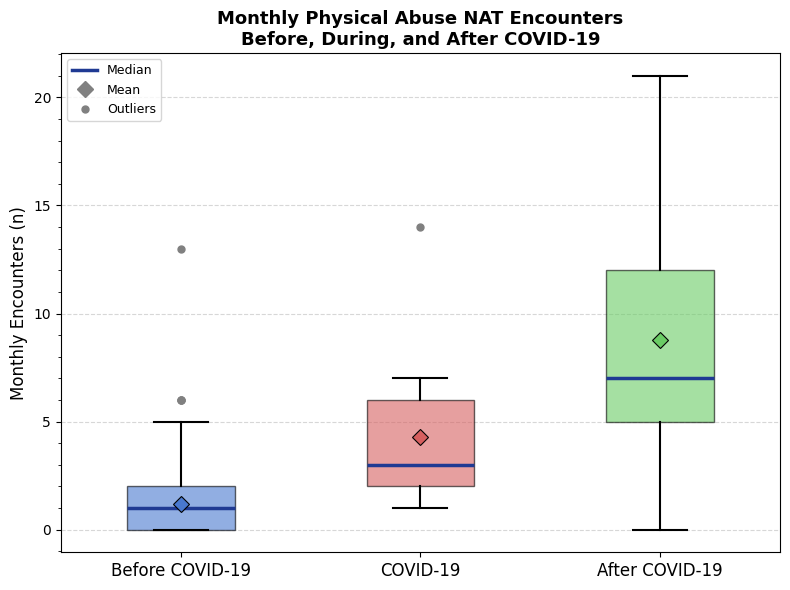

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 – Box plots of monthly encounter rate (Before / COVID / After)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("FIGURE 1: Box Plots of Monthly NAT Encounters")
print("="*70)

fig1_data   = [mc_before_full.values, mc_covid_full.values, mc_after_full.values]
fig1_labels = ["Before COVID-19", "COVID-19", "After COVID-19"]
fig1_colors = ["#4878CF", "#D65F5F", "#6ACC65"]

fig, ax = plt.subplots(figsize=(8, 6))

bp = ax.boxplot(
    fig1_data,
    patch_artist=True,
    notch=False,
    widths=0.45,
    medianprops=dict(color="#1F3A93", linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker="o", markersize=5, markerfacecolor="gray",
                    markeredgecolor="gray", linestyle="none"),
)

for patch, color in zip(bp["boxes"], fig1_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Add mean diamonds
for i, (data, color) in enumerate(zip(fig1_data, fig1_colors), start=1):
    mean_val = np.mean(data)
    ax.plot(i, mean_val, marker="D", color=color, markersize=8,
            markeredgecolor="black", markeredgewidth=0.8, zorder=5)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(fig1_labels, fontsize=12)
ax.set_ylabel("Monthly Encounters (n)", fontsize=12)
ax.set_title("Monthly Physical Abuse NAT Encounters\nBefore, During, and After COVID-19",
             fontsize=13, fontweight="bold")
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Legend
legend_elements = [
    Line2D([0], [0], color="#1F3A93", linewidth=2.5, label="Median"),
    Line2D([0], [0], marker="D", color="gray", linestyle="none",
           markersize=8, label="Mean"),
    Line2D([0], [0], marker="o", color="gray", linestyle="none",
           markersize=5, label="Outliers"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)

plt.tight_layout()
#plt.savefig("Figure1_Boxplots.png", dpi=300, bbox_inches="tight")
plt.show()


FIGURE 2: Yearly NAT Encounter Rate 2010–2023


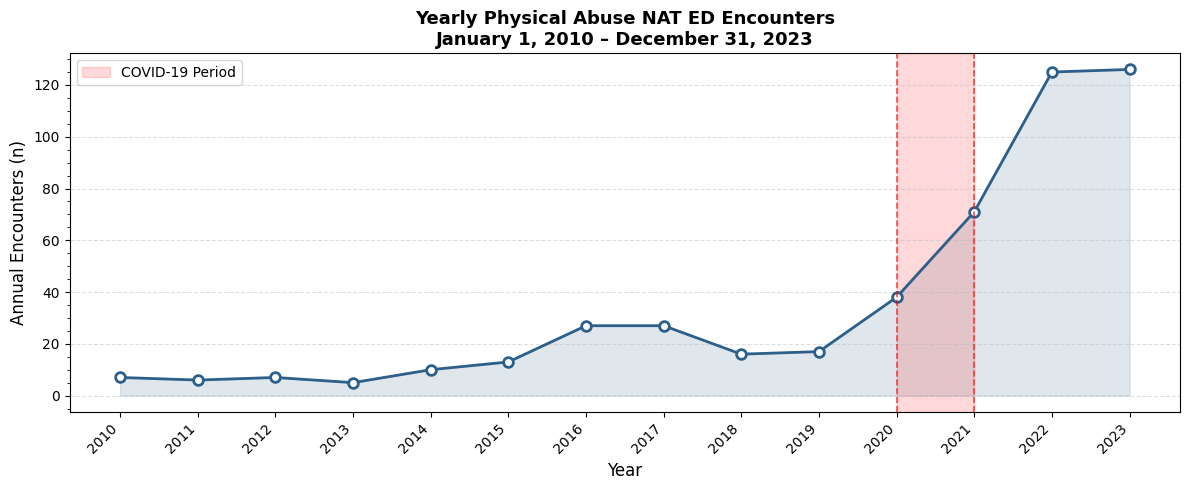

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 – Yearly encounter rate (2010–2023)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("FIGURE 2: Yearly NAT Encounter Rate 2010–2023")
print("="*70)

df_yr = df[df["AdmissionInstant"].dt.year.between(2010, 2023)].copy()
df_yr["Year"] = df_yr["AdmissionInstant"].dt.year
yearly = df_yr.groupby("Year").size().reset_index(name="Encounters")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(yearly["Year"], yearly["Encounters"],
        color="#2C5F8A", marker="o", linewidth=2, markersize=7,
        markerfacecolor="white", markeredgewidth=2)

ax.fill_between(yearly["Year"], yearly["Encounters"], alpha=0.15, color="#2C5F8A")

# COVID shading
ax.axvspan(2020, 2021, alpha=0.15, color="red", label="COVID-19 Period")
ax.axvline(x=2020, color="red", linestyle="--", linewidth=1.2, alpha=0.7)
ax.axvline(x=2021, color="red", linestyle="--", linewidth=1.2, alpha=0.7)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Annual Encounters (n)", fontsize=12)
ax.set_title("Yearly Physical Abuse NAT ED Encounters\nJanuary 1, 2010 – December 31, 2023",
             fontsize=13, fontweight="bold")
ax.set_xticks(yearly["Year"])
ax.set_xticklabels(yearly["Year"], rotation=45, ha="right")
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# **Table 5**

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TABLE 5 – Rural vs Urban (Chi-square, 3 windows)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("TABLE 5: Rural vs Urban Encounters — Physical Abuse Subgroup")
print("="*70)

# Use Rural_vs_Urban column; Unknown rows are excluded from the test
df["RUCA_Class"] = df["Rural_vs_Urban"].apply(
    lambda v: "Rural" if str(v).strip() == "Rural"
    else ("Urban" if str(v).strip() == "Urban" else "Unknown")
)

table5_rows = []

ruca_windows = {
    "Full study period": {
        "before": ("2010-01-01", "2020-02-29"),
        "covid":  ("2020-03-01", "2021-03-31"),
        "after":  ("2021-04-01", "2024-02-28"),
    },
    "2-year window": {
        "before": ("2018-03-01", "2020-02-29"),
        "covid":  ("2020-03-01", "2021-03-31"),
        "after":  ("2021-04-01", "2023-03-31"),
    },
    "1-year window": {
        "before": ("2019-03-01", "2020-02-29"),
        "covid":  ("2020-03-01", "2021-03-31"),
        "after":  ("2021-04-01", "2022-03-31"),
    },
}

for window_name, dates in ruca_windows.items():
    b_start, b_end = dates["before"]
    c_start, c_end = dates["covid"]
    a_start, a_end = dates["after"]

    df_w = df.copy()
    df_w["Period"] = df_w["AdmissionInstant"].apply(
        lambda dt: assign_period(dt, b_start, b_end, c_start, c_end, a_start, a_end)
    )
    df_w = df_w[(df_w["Period"] != "Out") & (df_w["RUCA_Class"] != "Unknown")]

    def ruca_counts(subset):
        u = (subset["RUCA_Class"] == "Urban").sum()
        r = (subset["RUCA_Class"] == "Rural").sum()
        return u, r

    u_b, r_b = ruca_counts(df_w[df_w["Period"] == "Before"])
    u_c, r_c = ruca_counts(df_w[df_w["Period"] == "COVID"])
    u_a, r_a = ruca_counts(df_w[df_w["Period"] == "After"])

    tot_b = u_b + r_b
    tot_c = u_c + r_c
    tot_a = u_a + r_a

    def pct(n, t): return f"{n} ({100*n/t:.1f}%)" if t > 0 else "0 (0.0%)"

    # Chi-square: 2 (Urban/Rural) x 3 (periods)
    ct = np.array([[u_b, u_c, u_a],
                   [r_b, r_c, r_a]])
    chi2_r, p_r, dof_r, _ = chi2_contingency(ct)

    print(f"\n  [{window_name}]")
    print(f"  {'':20} {'Before':>15} {'COVID-19':>15} {'After':>15}  p-value")
    print(f"  {'-'*70}")
    print(f"  {'Urban n(%)':20} {pct(u_b,tot_b):>15} {pct(u_c,tot_c):>15} {pct(u_a,tot_a):>15}  {p_r:.4f}")
    print(f"  {'Rural n(%)':20} {pct(r_b,tot_b):>15} {pct(r_c,tot_c):>15} {pct(r_a,tot_a):>15}")

    table5_rows.append({
        "Window": window_name,
        "Urban Before": pct(u_b, tot_b), "Urban COVID": pct(u_c, tot_c), "Urban After": pct(u_a, tot_a),
        "Rural Before": pct(r_b, tot_b), "Rural COVID": pct(r_c, tot_c), "Rural After": pct(r_a, tot_a),
        "Chi-square p-value": round(p_r, 4)
    })



TABLE 5: Rural vs Urban Encounters — Physical Abuse Subgroup

  [Full study period]
                                Before        COVID-19           After  p-value
  ----------------------------------------------------------------------
  Urban n(%)                75 (52.1%)      26 (47.3%)     131 (43.0%)  0.1899
  Rural n(%)                69 (47.9%)      29 (52.7%)     174 (57.0%)

  [2-year window]
                                Before        COVID-19           After  p-value
  ----------------------------------------------------------------------
  Urban n(%)                21 (51.2%)      26 (47.3%)      74 (40.7%)  0.3848
  Rural n(%)                20 (48.8%)      29 (52.7%)     108 (59.3%)

  [1-year window]
                                Before        COVID-19           After  p-value
  ----------------------------------------------------------------------
  Urban n(%)                10 (47.6%)      26 (47.3%)      27 (41.5%)  0.7856
  Rural n(%)                11 (52.4%) 

# **Table 4 - DCI Quintile**

In [ ]:
import pandas as pd
from scipy.stats import chisquare


# Step 1: Map Quintile → Category
mapping = {
    1: "Prosperous",
    2: "Comfortable",
    3: "Mid-Tier",
    4: "At-Risk",
    5: "Distressed"
}

df["Category"] = df["DCI Quintile"].map(mapping)

# Step 2: Count occurrences
counts = df["Category"].value_counts().reindex([
    "Prosperous", "Comfortable", "Mid-Tier", "At-Risk", "Distressed"
])

print(counts)

Category
Prosperous      50
Comfortable     59
Mid-Tier        57
At-Risk        102
Distressed     220
Name: count, dtype: int64


In [ ]:
# Chisquare test

chi2, p = chisquare(counts)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 209.06967213114757
p-value: 4.212048564548957e-44


In [ ]:
table4 = pd.DataFrame({
    "Zip Code – Level DCI Quintile": counts.index,
    "Number of encounters": counts.values
})

# Add p-value only in first row (like manuscript style)
table4["p-value"] = ""
table4.loc[0, "p-value"] = f"{p:.2e}"

print(table4)

  Zip Code – Level DCI Quintile  Number of encounters   p-value
0                    Prosperous                    50  4.21e-44
1                   Comfortable                    59          
2                      Mid-Tier                    57          
3                       At-Risk                   102          
4                    Distressed                   220          


# **Geospatial Analysis - Figure 3 (A)**

In [ ]:
 # ── Installs ─────────────────────────────────────────────

!pip install geopandas mapclassify --quiet

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")

# ── FILE PATHS ────────────────────────────────────────────
FILE_PATH      = "Physical Abuse - Final.xlsx"
SHAPEFILE_PATH = "tl_2020_us_zcta510.shp"

# ── LOAD DATA ─────────────────────────────────────────────────────────────────
df = pd.read_excel(FILE_PATH)
df["AdmissionInstant"] = pd.to_datetime(df["AdmissionInstant"])

# Filter to study date range: Jan 1, 2010 – Feb 1, 2024
df = df[
    (df["AdmissionInstant"] >= "2010-01-01") &
    (df["AdmissionInstant"] <= "2024-02-01")
].copy()

print(f"Total encounters in date range: {len(df)}")

Total encounters in date range: 504


In [ ]:
# ── CLEAN ZIP CODES ───────────────────────────────────────────────────────────
# Zip may be stored as float (e.g. 26505.0) or string – handle both
df["Zip_clean"] = (
    df["Zip"]
    .astype(str)
    .str.strip()
    .str.split(".").str[0]   # remove .0 if stored as float
    .str.zfill(5)
)

# Drop rows with missing/invalid zip
df = df[df["Zip_clean"].str.match(r"^\d{5}$")].copy()
print(f"Encounters with valid zip code: {len(df)}")

# ── AGGREGATE ENCOUNTERS BY ZIP ───────────────────────────────────────────────
zip_counts = (
    df.groupby("Zip_clean")
    .size()
    .reset_index(name="Encounters")
)
#print(f"Unique zip codes: {len(zip_counts)}")
#print(zip_counts.sort_values("Encounters", ascending=False).head(10))

# **Geospatial Analysis - WV Only**

In [ ]:
# ── Installs packages ─────────────────────────────────────────────
!pip install geopandas contextily pyproj --quiet
!wget https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_1_states_provinces.zip
!unzip -o ne_110m_admin_1_states_provinces.zip -d ne_states

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import contextily as ctx
import pyproj
import warnings
warnings.filterwarnings("ignore")

# ── FILE PATHS ────────────────────────────────────────────
FILE_PATH      = "Physical Abuse - Final.xlsx"
SHAPEFILE_PATH = "tl_2020_us_zcta510.shp"
NE_STATES_PATH = "ne_states/ne_110m_admin_1_states_provinces.shp"  # after wget + unzip

--2026-04-22 18:24:53--  https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_1_states_provinces.zip
Resolving naciscdn.org (naciscdn.org)... 3.174.255.115, 3.174.255.72, 3.174.255.128, ...
Connecting to naciscdn.org (naciscdn.org)|3.174.255.115|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 49304 (48K) [application/zip]
Saving to: ‘ne_110m_admin_1_states_provinces.zip’

ne_110m_admin_1_sta 100%[===================>]  48.15K   196KB/s    in 0.2s    

2026-04-22 18:24:54 (196 KB/s) - ‘ne_110m_admin_1_states_provinces.zip’ saved [49304/49304]

Archive:  ne_110m_admin_1_states_provinces.zip
  inflating: ne_states/ne_110m_admin_1_states_provinces.README.html  
 extracting: ne_states/ne_110m_admin_1_states_provinces.VERSION.txt  
 extracting: ne_states/ne_110m_admin_1_states_provinces.cpg  
  inflating: ne_states/ne_110m_admin_1_states_provinces.dbf  
  inflating: ne_states/ne_110m_admin_1_states_provinces.prj  
  inflating: ne_states/ne_110m_admin_1_stat

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 – Load encounter data & aggregate by zip
# ══════════════════════════════════════════════════════════════════════════════
df = pd.read_excel(FILE_PATH)
df["AdmissionInstant"] = pd.to_datetime(df["AdmissionInstant"])
df = df[
    (df["AdmissionInstant"] >= "2010-01-01") &
    (df["AdmissionInstant"] <= "2024-02-01")
].copy()

print(f"Encounters in date range: {len(df)}")

# Clean zip (handles float 26505.0, strings, missing leading zeros)
df["Zip_clean"] = (
    df["Zip"].astype(str).str.strip()
    .str.split(".").str[0]
    .str.zfill(5)
)
df = df[df["Zip_clean"].str.match(r"^\d{5}$")].copy()
print(f"Encounters with valid zip: {len(df)}")

zip_counts = df.groupby("Zip_clean").size().reset_index(name="Encounters")
print(f"Unique zip codes with encounters: {len(zip_counts)}")

Encounters in date range: 504
Encounters with valid zip: 504
Unique zip codes with encounters: 135


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 – Load WV state boundary (Natural Earth via wget above)
# ══════════════════════════════════════════════════════════════════════════════
states  = gpd.read_file(NE_STATES_PATH)
gdf_wv  = states[states["name"] == "West Virginia"].to_crs("EPSG:4326")
wv_union = gdf_wv.geometry.union_all() \
           if hasattr(gdf_wv.geometry, "union_all") \
           else gdf_wv.geometry.unary_union
print(f"\nWV boundary loaded. Bounds: {gdf_wv.total_bounds}")


WV boundary loaded. Bounds: [-82.58901018  37.19517326 -77.72279558  40.64111136]


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 – Load national ZCTA shapefile & clip to WV
# ══════════════════════════════════════════════════════════════════════════════
print("\nLoading ZCTA shapefile (may take ~30 sec)...")
gdf_all = gpd.read_file(SHAPEFILE_PATH)

zcta_col = [c for c in gdf_all.columns if "ZCTA" in c.upper()][0]
gdf_all  = gdf_all.rename(columns={zcta_col: "Zip_clean"})
gdf_all["Zip_clean"] = gdf_all["Zip_clean"].astype(str).str.zfill(5)
gdf_all  = gdf_all.to_crs("EPSG:4326")

# Centroid-based selection (fast)
gdf_all["_centroid"] = gdf_all.geometry.centroid
gdf_wv_zcta = gdf_all[gdf_all["_centroid"].within(wv_union)].copy()

# Also catch border ZCTAs whose centroid is just outside WV
gdf_border = gdf_all[
    ~gdf_all["Zip_clean"].isin(gdf_wv_zcta["Zip_clean"]) &
    gdf_all.geometry.intersects(wv_union)
].copy()

gdf_wv_zcta = pd.concat([gdf_wv_zcta, gdf_border], ignore_index=True)
gdf_wv_zcta = gdf_wv_zcta.drop(columns=["_centroid"])
print(f"WV ZCTAs found: {len(gdf_wv_zcta)}")

# ── Clip ZCTA polygons exactly to the WV state boundary ──────────────────────
# This removes any parts of border ZCTAs that stick into neighbouring states
gdf_wv_zcta = gpd.clip(gdf_wv_zcta, gdf_wv)
print(f"WV ZCTAs after clipping to state boundary: {len(gdf_wv_zcta)}")


Loading ZCTA shapefile (may take ~30 sec)...
WV ZCTAs found: 814
WV ZCTAs after clipping to state boundary: 814


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 – Merge encounter counts
# ══════════════════════════════════════════════════════════════════════════════
gdf_map = gdf_wv_zcta.merge(zip_counts, on="Zip_clean", how="left")
gdf_map["Encounters"] = gdf_map["Encounters"].fillna(0)

# Reproject to Web Mercator for contextily basemap
gdf_wv_merc   = gdf_wv.to_crs("EPSG:3857")
gdf_map_merc  = gdf_map.to_crs("EPSG:3857")

gdf_with    = gdf_map_merc[gdf_map_merc["Encounters"] > 0].copy()
gdf_without = gdf_map_merc[gdf_map_merc["Encounters"] == 0].copy()

print(f"\nZip codes with ≥1 encounter: {len(gdf_with)}")
print(f"Zip codes with 0 encounters:  {len(gdf_without)}")


Zip codes with ≥1 encounter: 110
Zip codes with 0 encounters:  704


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 – Project city coordinates to Web Mercator
# ══════════════════════════════════════════════════════════════════════════════
cities = {
    "Charleston":   (-81.6322, 38.3498),
    "Huntington":   (-82.4452, 38.4192),
    "Parkersburg":  (-81.5615, 39.2667),
    "Wheeling":     (-80.7209, 40.0640),
    "Beckley":      (-81.1879, 37.7782),
    "Clarksburg":   (-80.3445, 39.2806),
    "Fairmont":     (-80.1423, 39.4851),
}
morgantown_lonlat = (-79.9559, 39.6295)

def lonlat_to_merc(lon, lat):
    t = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    return t.transform(lon, lat)

cities_merc   = {name: lonlat_to_merc(*c) for name, c in cities.items()}
morgantown_xy = lonlat_to_merc(*morgantown_lonlat)

Basemap added successfully.


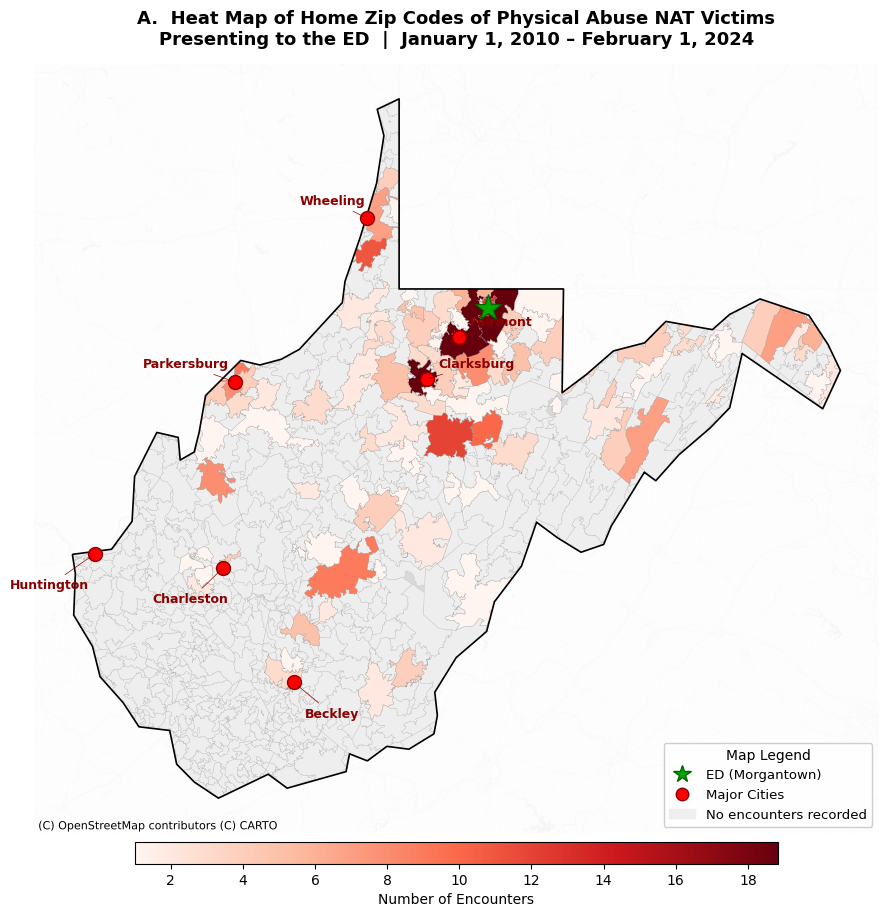

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 – Plot
# ══════════════════════════════════════════════════════════════════════════════
heat_cmap = LinearSegmentedColormap.from_list(
    "nat_heat",
    ["#fff5f0", "#fcbba1", "#fb6a4a", "#cb181d", "#67000d"],
    N=256
)

fig, ax = plt.subplots(figsize=(12, 10))

# ── Layer 1: WV state fill (solid light grey background) ─────────────────────
gdf_wv_merc.plot(ax=ax, color="#d9d9d9", edgecolor="none", zorder=1)

# ── Layer 2: ZCTA polygons with zero encounters (slightly lighter grey) ───────
gdf_without.plot(
    ax=ax,
    color="#eeeeee",
    edgecolor="#bbbbbb",
    linewidth=0.2,
    zorder=2
)

# ── Layer 3: ZCTA polygons WITH encounters (heat colours) ────────────────────
vmax = max(gdf_with["Encounters"].quantile(0.97), 1)

gdf_with.plot(
    column="Encounters",
    ax=ax,
    cmap=heat_cmap,
    linewidth=0.2,
    edgecolor="#999999",
    vmin=1,
    vmax=vmax,
    zorder=3,
    legend=False,   # manual colorbar below
)

# ── Layer 4: WV state boundary outline (clean black border) ──────────────────

gdf_wv_merc.boundary.plot(ax=ax, color="black", linewidth=1.2, zorder=6)

# ── Layer 5: Contextily basemap (light road map as subtle background) ─────────

try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.PositronNoLabels,
        zoom=8,
        alpha=0.25,    # very subtle so the heat colours dominate
        zorder=0       # behind everything
    )
    print("Basemap added successfully.")
except Exception as e:
    print(f"Basemap skipped (no internet or contextily error): {e}")

# ── Layer 6: Green star – ED in Morgantown ────────────────────────────────────

ax.plot(*morgantown_xy, marker="*", color="#00a800", markersize=20,
        markeredgecolor="darkgreen", markeredgewidth=0.8, zorder=10)

# ── Layer 7: Red circles – major cities ──────────────────────────────────────

label_offsets_merc = {
    "Charleston":  (-50000, -25000),
    "Huntington":  (-60000, -25000),
    "Parkersburg": (-65000,  10000),
    "Wheeling":    (-48000,  10000),
    "Beckley":     (  8000, -25000),
    "Clarksburg":  (  8000,   8000),
    "Fairmont":    (  8000,   8000),
}
for city, (x, y) in cities_merc.items():
    ax.plot(x, y, marker="o", color="red", markersize=10,
            markeredgecolor="darkred", markeredgewidth=1.0, zorder=9)
    ox, oy = label_offsets_merc.get(city, (8000, 8000))
    ax.annotate(
        city,
        xy=(x, y), xytext=(x + ox, y + oy),
        fontsize=9, color="darkred", fontweight="bold",
        arrowprops=dict(arrowstyle="-", color="darkred", lw=0.5),
        zorder=11,
    )

# ── Manual colorbar ───────────────────────────────────────────────────────────

norm = Normalize(vmin=1, vmax=vmax)
sm   = ScalarMappable(cmap=heat_cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal",
                    shrink=0.55, pad=0.01, aspect=30)
cbar.set_label("Number of Encounters", fontsize=10)

# ── Legend ────────────────────────────────────────────────────────────────────

star_h   = Line2D([0],[0], marker="*", color="#00a800", markersize=13,
                  linestyle="none", markeredgecolor="darkgreen",
                  label="ED (Morgantown)")
circle_h = Line2D([0],[0], marker="o", color="red",    markersize=9,
                  linestyle="none", markeredgecolor="darkred",
                  label="Major Cities")
grey_h   = mpatches.Patch(color="#eeeeee", edgecolor="#bbbbbb",
                          label="No encounters recorded")

ax.legend(handles=[star_h, circle_h, grey_h],
          loc="lower right", fontsize=9.5, framealpha=0.95,
          title="Map Legend", title_fontsize=10)

# ── Title & finish ────────────────────────────────────────────────────────────
ax.set_title(
    "A.  Heat Map of Home Zip Codes of Physical Abuse NAT Victims\n"
    "Presenting to the ED  |  January 1, 2010 – February 1, 2024",
    fontsize=13, fontweight="bold", pad=14
)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("Figure3A_Heatmap_Final.png", dpi=300, bbox_inches="tight")
plt.show()